## EDA ON REVIEWS DATASET

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
app = pd.read_csv('../datasets/cleaned_apps.csv')

rev = pd.read_csv('../datasets/cleaned_reviews.csv')

In [8]:
print('Statistics for numeric columns in Reviews Dataset')

rev.describe()

Statistics for numeric columns in Reviews Dataset


,Sentiment_Polarity,Sentiment_Subjectivity
count,37427.000000,37427.000000
mean,0.182171,0.492770
std,0.351318,0.259904
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


In [9]:
app['App'] = app['App'].str.strip()
rev['App'] = rev['App'].str.strip()

In [10]:
merged_df = app.merge(rev, on='App',how='inner')
merged_df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Hay Day,FAMILY,4.5,10053186,94M,100000000,Free,0.0,Everyone,Casual,2018-06-28,1_39_93,4.0.3 and up,I wanting couple changes 1. I would like boat ...,Positive,0.091667,0.308333
1,Hay Day,FAMILY,4.5,10053186,94M,100000000,Free,0.0,Everyone,Casual,2018-06-28,1_39_93,4.0.3 and up,"I love game!! I play much possible, since I ki...",Positive,0.171875,0.567063
2,Hay Day,FAMILY,4.5,10053186,94M,100000000,Free,0.0,Everyone,Casual,2018-06-28,1_39_93,4.0.3 and up,Why connect Facebook anymore? It connects 1 se...,Positive,0.166250,0.490000
3,Hay Day,FAMILY,4.5,10053186,94M,100000000,Free,0.0,Everyone,Casual,2018-06-28,1_39_93,4.0.3 and up,Thank you! I highly addicted game. But aggrava...,Negative,-0.500000,0.600000
4,Hay Day,FAMILY,4.5,10053186,94M,100000000,Free,0.0,Everyone,Casual,2018-06-28,1_39_93,4.0.3 and up,7/24/18- I reinstalled game issues far. I woul...,Negative,-0.100000,0.471429


In [11]:
print('Dimesnions of merged dataset\n', merged_df.shape,'\n')
merged_df.info()

Dimesnions of merged dataset
 (35929, 17) 

<class 'pandas.DataFrame'>
RangeIndex: 35929 entries, 0 to 35928
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     35929 non-null  str    
 1   Category                35929 non-null  str    
 2   Rating                  35929 non-null  float64
 3   Reviews                 35929 non-null  int64  
 4   Size                    35929 non-null  str    
 5   Installs                35929 non-null  int64  
 6   Type                    35929 non-null  str    
 7   Price                   35929 non-null  float64
 8   Content Rating          35929 non-null  str    
 9   Genres                  35929 non-null  str    
 10  Last Updated            35929 non-null  str    
 11  Current Ver             35929 non-null  str    
 12  Android Ver             35929 non-null  str    
 13  Translated_Review       35929 non-null  str    
 14  Senti

In [12]:
merged_df.isnull().sum()

merged_df.duplicated().sum()

merged_df.describe()

,Rating,Reviews,Installs,Price,Sentiment_Polarity,Sentiment_Subjectivity
count,35929.000000,3.592900e+04,3.592900e+04,35929.000000,35929.000000,35929.000000
mean,4.296590,1.414028e+06,4.375733e+07,0.109197,0.180904,0.493767
std,0.302795,5.734136e+06,1.453464e+08,1.302471,0.350080,0.258053
min,2.600000,1.140000e+02,1.000000e+03,0.000000,-1.000000,0.000000
25%,4.100000,1.024700e+04,1.000000e+06,0.000000,0.000000,0.361111
50%,4.300000,6.362400e+04,5.000000e+06,0.000000,0.150000,0.514835
75%,4.500000,5.156570e+05,1.000000e+07,0.000000,0.400000,0.650000
max,4.900000,7.815831e+07,1.000000e+09,29.990000,1.000000,1.000000


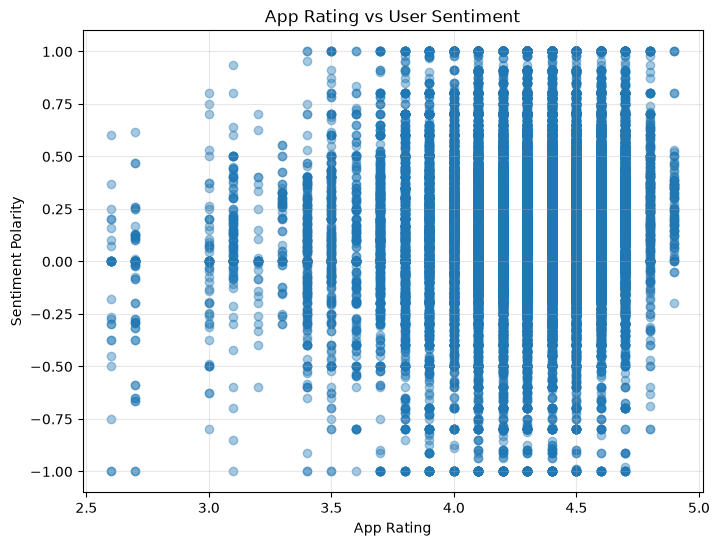

                      Rating  Sentiment_Polarity
Rating              1.000000            0.092329
Sentiment_Polarity  0.092329            1.000000


In [13]:

plt.figure(figsize=(8,6))

plt.scatter(
    merged_df['Rating'],
    merged_df['Sentiment_Polarity'],
    alpha=0.4
)

plt.xlabel('App Rating')
plt.ylabel('Sentiment Polarity')
plt.title('App Rating vs User Sentiment')

plt.grid(alpha=0.3)
plt.show()

print(merged_df[['Rating','Sentiment_Polarity']].corr())

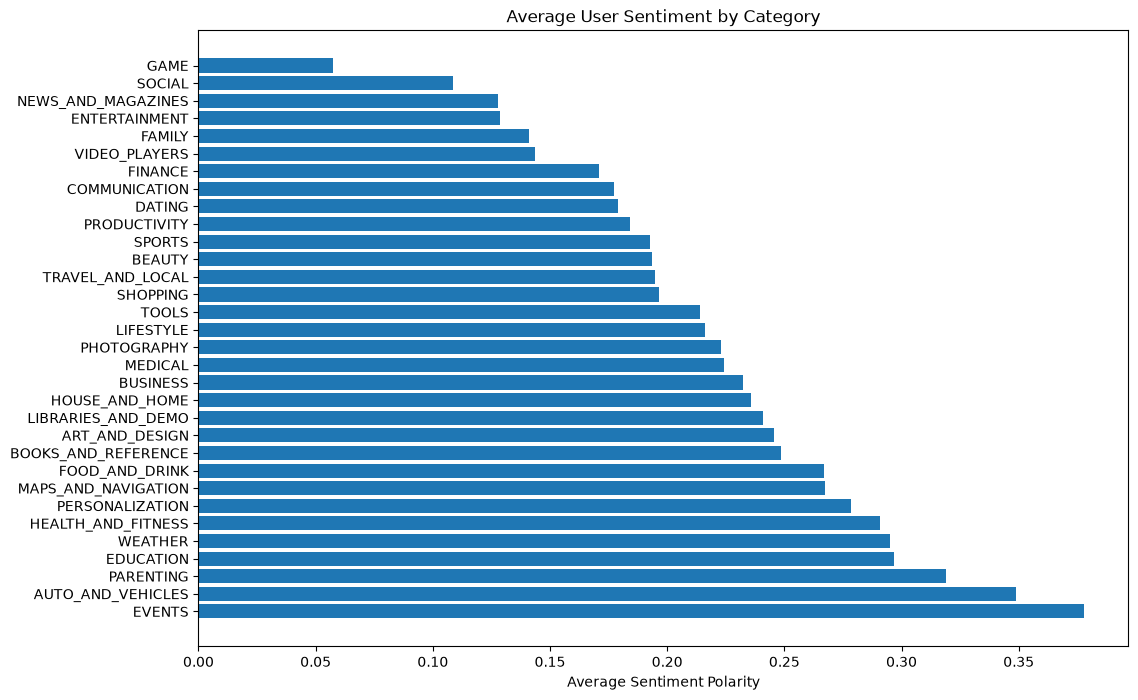

In [15]:
category_sentiment = (
    merged_df.groupby('Category')
             .agg(
                 Avg_Sentiment=('Sentiment_Polarity','mean'),
                 Reviews=('Sentiment_Polarity','count')
             )
             .query("Reviews >= 100")
             .sort_values('Avg_Sentiment', ascending=False)
)

plt.figure(figsize=(12,8))

plt.barh(
    category_sentiment.index,
    category_sentiment['Avg_Sentiment']
)

plt.xlabel("Average Sentiment Polarity")
plt.title("Average User Sentiment by Category")

plt.show()

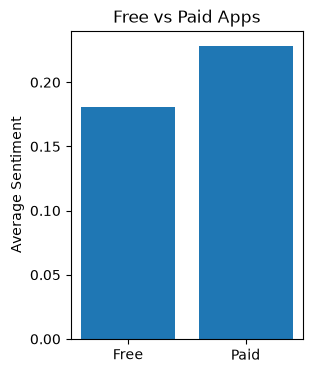

,Avg_Sentiment,Avg_Rating
Type,,
Free,0.180346,4.296291
Paid,0.228548,4.322115


In [ ]:
type_sentiment = (
    merged_df.groupby('Type')
             .agg(
                 Avg_Sentiment=('Sentiment_Polarity','mean'),
                 Avg_Rating=('Rating','mean')
             )
)

plt.figure(figsize=(3,4))


plt.bar(
    type_sentiment.index,
    type_sentiment['Avg_Sentiment']
)

plt.ylabel("Average Sentiment")
plt.title("Free vs Paid Apps")

plt.show()

type_sentiment


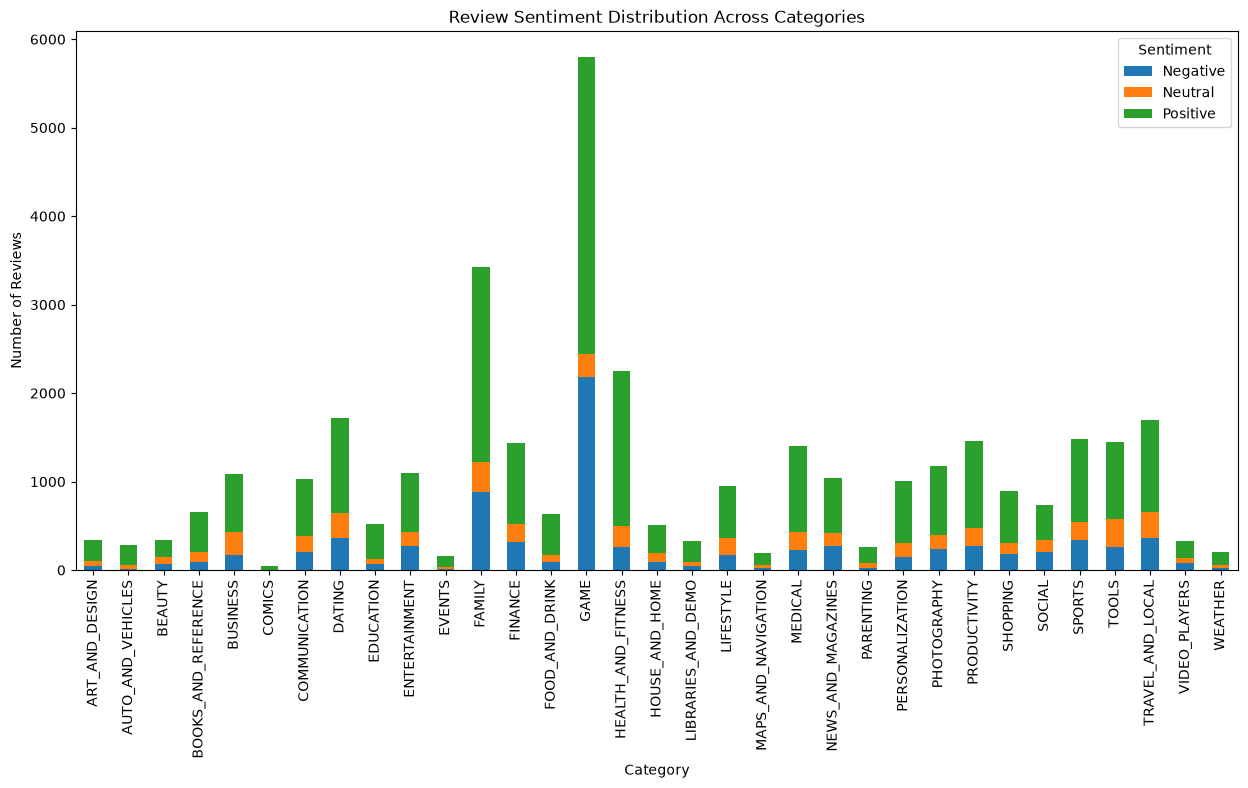

In [ ]:
sentiment_dist = (
    merged_df.groupby(['Category','Sentiment'])
             .size()
             .unstack(fill_value=0)
)

sentiment_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(15,7)
)

plt.ylabel("Number of Reviews")
plt.title("Review Sentiment Distribution Across Categories")

plt.show()

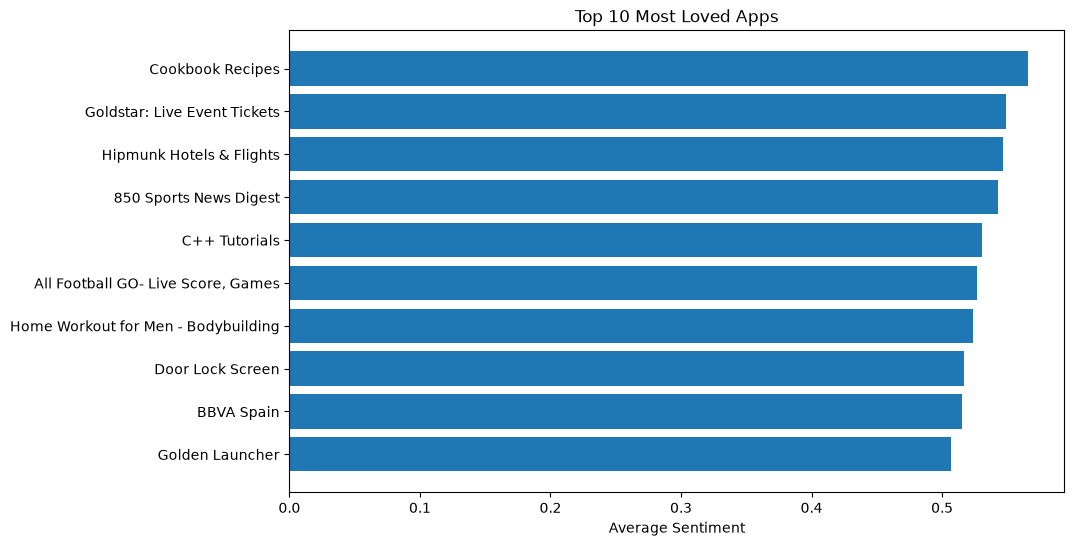

In [ ]:
app_sentiment = (
    merged_df.groupby('App')
             .agg(
                 Avg_Sentiment=('Sentiment_Polarity','mean'),
                 Reviews=('Sentiment_Polarity','count'),
                 Rating=('Rating','mean')
             )
)

app_sentiment = app_sentiment.query("Reviews >= 20")

top_apps = app_sentiment.nlargest(10,'Avg_Sentiment')

plt.figure(figsize=(10,6))

plt.barh(
    top_apps.index,
    top_apps['Avg_Sentiment']
)

plt.title("Top 10 Most Loved Apps")

plt.xlabel("Average Sentiment")

plt.gca().invert_yaxis()

plt.show()

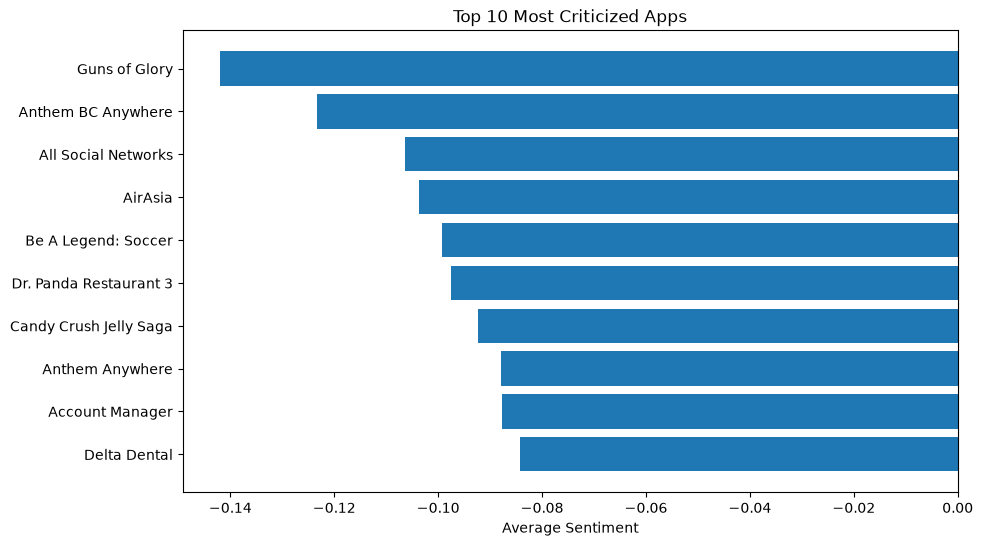

In [ ]:
bottom_apps = app_sentiment.nsmallest(10,'Avg_Sentiment')

plt.figure(figsize=(10,6))

plt.barh(
    bottom_apps.index,
    bottom_apps['Avg_Sentiment']
)

plt.title("Top 10 Most Criticized Apps")

plt.xlabel("Average Sentiment")

plt.gca().invert_yaxis()

plt.show()

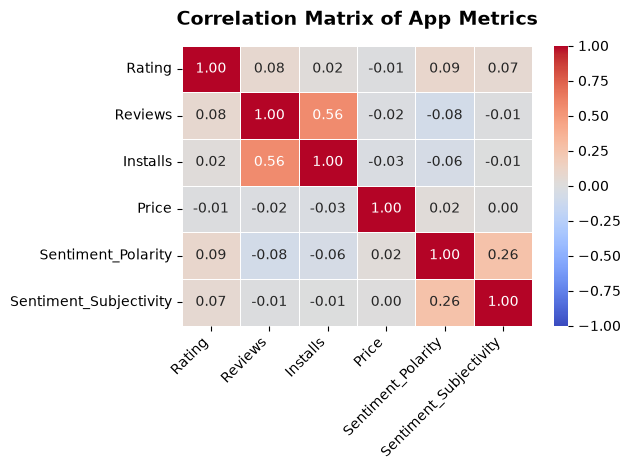

In [ ]:
numeric_cols = [
    'Rating',
    'Reviews',
    'Installs',
    'Price',
    'Sentiment_Polarity',
    'Sentiment_Subjectivity'
]

corr_matrix = merged_df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,   
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=0.5,      
    vmin=-1, vmax=1    
)
plt.xticks(rotation=45, ha='right')

plt.title('Correlation Matrix of App Metrics', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()